# Step 7 — Component ablation and sensitivity analysis of the final model

**Final model:** generative cultural context (Qwen2.5-VL descriptions) + LEACE culture erasure + Consensus–Deviation Decomposition (CDD) + Group DRO, trained on soft labels.

This notebook removes **one component at a time** and varies CDD's two settings, using exactly the same 5×5 meme-grouped CV as Steps 3–6.

| run | context | LEACE | head | Group DRO | soft labels | β | γ |
|---|---|---|---|---|---|---|---|
| `full` | ✓ | ✓ | CDD | ✓ | ✓ | 0.5 | 0.05 |
| `no_context` | – | ✓ | CDD | ✓ | ✓ | 0.5 | 0.05 |
| `no_leace` | ✓ | – | CDD | ✓ | ✓ | 0.5 | 0.05 |
| `no_cdd` | ✓ | ✓ | culture FiLM | ✓ | ✓ | – | – |
| `no_dro` | ✓ | ✓ | CDD | – | ✓ | 0.5 | 0.05 |
| `no_soft` | ✓ | ✓ | CDD | ✓ | – | 0.5 | 0.05 |
| `plain_ctx` | ✓ | – | plain | – | – | – | – |
| `beta{0, 0.25, 1}` | ✓ | ✓ | CDD | ✓ | ✓ | varied | 0.05 |
| `gamma{0, 0.01, 0.2}` | ✓ | ✓ | CDD | ✓ | ✓ | 0.5 | varied |

`beta0` removes the cross-cultural consensus target entirely; `gamma0` removes the shrinkage of cultural deviations.

**Where the Step 6 features come from (automatic):**
1. `feats_siglip2_ctx.npz` in this session's Output folder (`/kaggle/working`), e.g. when run inside the Step 6 session; else
2. `feats_siglip2_ctx.npz` in any attached input; else
3. it is **rebuilt** from `vlm_outputs.csv` found in any attached input (your `step6results` dataset contains it). This needs **Internet On** and adds ~10 min.

**Always use Run All** (or Save Version → Save & Run All): the cells depend on each other and must run top to bottom.

**Kaggle:** GPU T4, Internet On, ~2–2.5 h. Finished runs are skipped on re-run.


In [3]:
# ---- Setup: imports, file lookup, and where the Step 6 features come from ----
import glob, json, math, os, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from types import SimpleNamespace
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
import warnings; warnings.filterwarnings("ignore", category=UserWarning)

def find(name):
    """Look in this session's Output folder first, then in every attached input (datasets or notebooks)."""
    hits = sorted(glob.glob(f"/kaggle/working/**/{name}", recursive=True)) + \
           sorted(glob.glob(f"/kaggle/input/**/{name}", recursive=True))
    return hits[0] if hits else None

RESULTS = "/kaggle/working/results_step7"
os.makedirs(RESULTS, exist_ok=True)

FEATURES = {"siglip2": find("feats_siglip2.npz")}      # only used if the context features must be rebuilt
FEATURES_CTX = find("feats_siglip2_ctx.npz")           # Step 6 context features (preferred)
VLM_PREV = find("vlm_outputs.csv")                     # Step 6 descriptions (fallback source)
NEED_BUILD = FEATURES_CTX is None

print("Output folder :", sorted(os.listdir("/kaggle/working")))
print("Context feats :", FEATURES_CTX)
print("vlm_outputs   :", VLM_PREV)
if NEED_BUILD:
    assert VLM_PREV, ("Neither feats_siglip2_ctx.npz nor vlm_outputs.csv was found. Attach your Step 6 results "
                      "(e.g. the step6results dataset, which contains vlm_outputs.csv) via Add Input.")
    print("\n-> feats_siglip2_ctx.npz not found: it will be REBUILT from vlm_outputs.csv "
          "(needs Internet On and a GPU, ~10 min).")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=4.49"], check=True)
else:
    print("\n-> Using existing context features; nothing will be rebuilt.")


Output folder : ['.virtual_documents', 'Multi3Hate', 'results_step7']
Context feats : None
vlm_outputs   : /kaggle/input/datasets/zee8885/step6results/vlm_outputs.csv

-> feats_siglip2_ctx.npz not found: it will be REBUILT from vlm_outputs.csv (needs Internet On and a GPU, ~10 min).


In [4]:
# ---- Rebuild the context features only if they were not attached ----
if NEED_BUILD:
    # ---- Dataset table (needs the meme images) and SigLIP 2 features ----
    import subprocess, gc
    from PIL import Image

    REPO = "/kaggle/working/Multi3Hate"
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/MinhDucBui/Multi3Hate.git", REPO], check=True)
    DATA = f"{REPO}/data"
    LANG2CULT = {"en": "US", "de": "DE", "es": "MX", "hi": "IN", "zh": "CN"}
    final = pd.read_csv(f"{DATA}/final_annotations.csv")
    raw = pd.read_csv(f"{DATA}/raw_annotations.csv").dropna(subset=["hatespeech"])
    votes = raw.groupby(["dataset_language", "Meme ID"])["hatespeech"].agg(n_hate="sum", n_total="count")
    img_index = {(p.split("/")[-3], int(os.path.splitext(os.path.basename(p))[0])): p
                 for p in glob.glob(f"{DATA}/memes/*/*/*")}
    rows = []
    for lang, cult in LANG2CULT.items():
        for _, r in pd.read_csv(f"{DATA}/captions/{lang}.csv").iterrows():
            mid = int(r["Meme ID"])
            v = votes.loc[(lang, mid)]
            rows.append({"meme_id": mid, "culture": cult, "language": lang, "image_path": img_index[(lang, mid)],
                         "text": str(r["Translation"]).replace("<sep>", " / "),
                         "n_hate": int(v["n_hate"]), "n_total": int(v["n_total"]),
                         "label": int(final.loc[final["Meme ID"] == mid, cult].iloc[0])})
    df = pd.DataFrame(rows).sort_values(["meme_id", "culture"]).reset_index(drop=True)
    print("table:", df.shape)

    def as_tensor(out):
        if isinstance(out, torch.Tensor):
            return out
        for key in ("pooler_output", "image_embeds", "text_embeds"):
            v = getattr(out, key, None)
            if isinstance(v, torch.Tensor):
                return v
        raise TypeError(type(out))

    if not FEATURES.get("siglip2"):
        from transformers import AutoModel, AutoProcessor
        mid = "google/siglip2-base-patch16-224"
        sm = AutoModel.from_pretrained(mid).to("cuda").eval()
        sp = AutoProcessor.from_pretrained(mid)
        img, txt = [], []
        with torch.no_grad():
            for i in range(0, len(df), 32):
                ch = df.iloc[i:i + 32]
                ims = [Image.open(p).convert("RGB") for p in ch.image_path]
                img.append(F.normalize(as_tensor(sm.get_image_features(**sp(images=ims, return_tensors="pt").to("cuda"))).float(), dim=-1).cpu().numpy())
                t = sp(text=[s.lower() for s in ch.text], padding="max_length", max_length=64, truncation=True, return_tensors="pt").to("cuda")
                txt.append(F.normalize(as_tensor(sm.get_text_features(**t)).float(), dim=-1).cpu().numpy())
        img, txt = np.concatenate(img), np.concatenate(txt)
        FEATURES["siglip2"] = "/kaggle/working/feats_siglip2.npz"
        np.savez(FEATURES["siglip2"], X=np.concatenate([img, txt], 1).astype(np.float32), img_dim=img.shape[1],
                 culture=df.culture.values.astype(str), meme_id=df.meme_id.values.astype(str),
                 y_soft=(df.n_hate / df.n_total).values.astype(np.float32), y_hard=df.label.values.astype(np.int64))
        del sm; gc.collect(); torch.cuda.empty_cache()
    print("SigLIP 2 features:", FEATURES["siglip2"])
    # ---- 3) Free the VLM and embed the descriptions with multilingual-E5 ----
    gc.collect(); torch.cuda.empty_cache()
    from transformers import AutoTokenizer, AutoModel
    E5 = "intfloat/multilingual-e5-base"
    etok = AutoTokenizer.from_pretrained(E5)
    emod = AutoModel.from_pretrained(E5).to("cuda").eval()

    vlm_out = pd.read_csv(VLM_PREV)
    ctx = df[["meme_id", "culture"]].merge(vlm_out, on=["meme_id", "culture"], how="left")
    assert ctx["description"].notna().all(), "some descriptions are missing - re-run the generation cell"
    emb = []
    with torch.no_grad():
        for i in range(0, len(ctx), 64):
            batch = ["passage: " + str(t) for t in ctx.description.iloc[i:i + 64]]
            t = etok(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to("cuda")
            h = emod(**t).last_hidden_state
            m = t["attention_mask"].unsqueeze(-1).float()
            emb.append(F.normalize((h * m).sum(1) / m.sum(1), dim=-1).cpu().numpy())
    emb = np.concatenate(emb).astype(np.float32)
    del emod; gc.collect(); torch.cuda.empty_cache()
    print("description embeddings:", emb.shape)
    # ---- 4) Build feature files ----
    base = np.load(FEATURES["siglip2"], allow_pickle=True)
    assert (base["meme_id"].astype(str) == df.meme_id.astype(str).values).all() and \
           (base["culture"].astype(str) == df.culture.values).all(), "row order mismatch"
    zs = ctx[["p_yes_persona"]].values.astype(np.float32)
    common = dict(culture=base["culture"], meme_id=base["meme_id"], y_soft=base["y_soft"], y_hard=base["y_hard"])
    FEATURES_CTX = "/kaggle/working/feats_siglip2_ctx.npz"
    FEATURES_CTXONLY = "/kaggle/working/feats_ctx_only.npz"
    np.savez(FEATURES_CTX, X=np.concatenate([base["X"], emb, zs], 1).astype(np.float32), img_dim=int(base["img_dim"]), **common)
    np.savez(FEATURES_CTXONLY, X=np.concatenate([emb, zs], 1).astype(np.float32), img_dim=0, **common)
    print("saved", FEATURES_CTX, "and", FEATURES_CTXONLY)

table: (1500, 8)


config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

description embeddings: (1500, 768)
saved /kaggle/working/feats_siglip2_ctx.npz and /kaggle/working/feats_ctx_only.npz


In [5]:
# ---- No-context feature file: the SigLIP 2 part of the context features ----
zc = np.load(FEATURES_CTX, allow_pickle=True)
N_CTX = 768 + 1          # multilingual-E5 description embedding + zero-shot persona probability
assert zc["X"].shape[1] == 1536 + N_CTX, f"unexpected feature width {zc['X'].shape}"
FEATURES_NOCTX = "/kaggle/working/feats_siglip2_noctx.npz"
np.savez(FEATURES_NOCTX, X=zc["X"][:, :-N_CTX], img_dim=int(zc["img_dim"]), culture=zc["culture"],
         meme_id=zc["meme_id"], y_soft=zc["y_soft"], y_hard=zc["y_hard"])
print("context:", zc["X"].shape, "| no context:", zc["X"][:, :-N_CTX].shape)

context: (1500, 2305) | no context: (1500, 1536)


In [6]:
# ---- Shared evaluation metrics ----
import numpy as np
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix)

CULTURES = ["US", "DE", "MX", "IN", "CN"]


def _f(x):
    """Plain float for JSON; NaN -> None."""
    if x is None:
        return None
    x = float(x)
    return None if np.isnan(x) else x


def safe_auc(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan


def safe_bal_acc(y, yhat):
    return balanced_accuracy_score(y, yhat) if len(np.unique(y)) == 2 else np.nan


def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            ece += m.mean() * abs(y[m].mean() - p[m].mean())
    return ece


def bernoulli_jsd(q, p, eps=1e-6):
    """Jensen-Shannon divergence (bits) between Bernoulli(q) and Bernoulli(p)."""
    q = np.clip(q, eps, 1 - eps)
    p = np.clip(p, eps, 1 - eps)
    m = 0.5 * (q + p)

    def kl(a, b):
        return a * np.log2(a / b) + (1 - a) * np.log2((1 - a) / (1 - b))

    return 0.5 * kl(q, m) + 0.5 * kl(p, m)


def _spread(vals):
    v = np.array([x for x in vals if x is not None and not np.isnan(x)], dtype=float)
    return (v.max() - v.min()) if len(v) else np.nan


def evaluate(y_true, y_prob, culture, y_soft=None, thr=0.5):
    """Full metric set: overall, per-culture, fairness gaps, calibration, soft-label fit."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    culture = np.asarray(culture).astype(str)
    y_pred = (y_prob >= thr).astype(int)

    out = {
        "n": int(len(y_true)),
        "threshold": _f(np.mean(thr)),
        "pos_rate_true": _f(y_true.mean()),
        "pos_rate_pred": _f(y_pred.mean()),
        "accuracy": _f(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": _f(safe_bal_acc(y_true, y_pred)),
        "macro_f1": _f(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_hate": _f(f1_score(y_true, y_pred, zero_division=0)),
        "auroc": _f(safe_auc(y_true, y_prob)),
        "ece": _f(expected_calibration_error(y_true, y_prob)),
        "constant_all_hate_acc": _f(y_true.mean()),  # reference only
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    }
    out["degenerate"] = bool(out["pos_rate_pred"] > 0.95 or out["pos_rate_pred"] < 0.05)

    per = {}
    for c in [k for k in CULTURES if k in set(culture)] + sorted(set(culture) - set(CULTURES)):
        m = culture == c
        yt, yp = y_true[m], y_pred[m]
        per[c] = {
            "n": int(m.sum()),
            "hate_prevalence": _f(yt.mean()),
            "accuracy": _f((yt == yp).mean()),
            "balanced_accuracy": _f(safe_bal_acc(yt, yp)),
            "tpr": _f(yp[yt == 1].mean()) if (yt == 1).any() else None,
            "fpr": _f(yp[yt == 0].mean()) if (yt == 0).any() else None,
            "pos_rate_pred": _f(yp.mean()),
        }
    out["per_culture"] = per

    def col(key):
        return [np.nan if v[key] is None else v[key] for v in per.values()]

    accs, bals = col("accuracy"), col("balanced_accuracy")
    out["worst_culture_acc"] = _f(np.nanmin(accs))
    out["worst_culture_bal_acc"] = _f(np.nanmin(bals)) if not np.all(np.isnan(bals)) else None
    out["bias_gap_acc"] = _f(_spread(accs))
    out["bias_gap_bal_acc"] = _f(_spread(bals))
    out["tpr_gap"] = _f(_spread(col("tpr")))
    out["fpr_gap"] = _f(_spread(col("fpr")))
    gaps = [g for g in (out["tpr_gap"], out["fpr_gap"]) if g is not None]
    out["equalized_odds_gap"] = _f(max(gaps)) if gaps else None
    # What a constant "hate" predictor would score as a bias gap on this split:
    out["constant_predictor_bias_gap"] = _f(_spread(col("hate_prevalence")))

    if y_soft is not None:
        q = np.asarray(y_soft, dtype=float)
        p = np.clip(y_prob, 1e-6, 1 - 1e-6)
        out["soft_bce"] = _f(np.mean(-(q * np.log(p) + (1 - q) * np.log(1 - p))))
        out["soft_jsd"] = _f(np.mean(bernoulli_jsd(q, y_prob)))
    return out

In [7]:
# ---- LEACE: closed-form least-squares concept erasure (Belrose et al., 2023) ----
def fit_leace(X, c, n_cls, eps=1e-6):
    """Returns (mu, E) such that x' = x - (x - mu) @ E.T removes all linear information about c."""
    X = X.astype(np.float64)
    mu = X.mean(0)
    Xc = X - mu
    Z = np.eye(n_cls)[c]
    Zc = Z - Z.mean(0)
    n = len(X)
    Sxx = Xc.T @ Xc / n
    Sxz = Xc.T @ Zc / n
    evals, evecs = np.linalg.eigh(Sxx)
    keep = evals > eps * evals.max()
    V, ev = evecs[:, keep], evals[keep]
    W = V @ np.diag(ev ** -0.5) @ V.T          # whitening
    W_pinv = V @ np.diag(ev ** 0.5) @ V.T      # its pseudo-inverse
    U, s, _ = np.linalg.svd(W @ Sxz, full_matrices=False)
    U = U[:, s > 1e-8 * s.max()]
    E = W_pinv @ (U @ U.T) @ W
    return mu, E

def apply_leace(X, mu, E):
    return (X - (X - mu) @ E.T).astype(np.float32)

In [8]:
# ---- Model, training, probes, baselines ----
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, g):
        return -ctx.lam * g, None


class CCAL(nn.Module):
    def __init__(self, in_dim, hid, n_cult, cult_dim, p, adv, conditioned):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hid, hid), nn.ReLU(), nn.Dropout(p))
        self.conditioned = conditioned
        if conditioned:
            self.cult_emb = nn.Embedding(n_cult, cult_dim)
            self.film = nn.Linear(cult_dim, 2 * hid)
            nn.init.zeros_(self.film.weight); nn.init.zeros_(self.film.bias)  # start as identity
        self.head = nn.Sequential(nn.Linear(hid, 128), nn.ReLU(), nn.Dropout(p), nn.Linear(128, 1))
        self.adv_type = adv
        if adv != "none":
            extra = 2 if adv == "cond_grl" else 0
            self.adv = nn.Sequential(nn.Linear(hid + extra, 128), nn.ReLU(), nn.Dropout(p),
                                     nn.Linear(128, n_cult))

    def forward(self, x, c, y_hard=None, lam=0.0, with_adv=False):
        z = self.enc(x)
        h = z
        if self.conditioned:
            g, b = self.film(self.cult_emb(c)).chunk(2, dim=-1)
            h = z * (1 + g) + b
        logit = self.head(h).squeeze(-1)
        adv_logit = None
        if with_adv and self.adv_type != "none":
            zr = GradReverse.apply(z, lam)
            if self.adv_type == "cond_grl":
                zr = torch.cat([zr, F.one_hot(y_hard, 2).float()], dim=-1)
            adv_logit = self.adv(zr)
        return logit, adv_logit, z


def lam_at(epoch, total, lam_max):
    p = epoch / max(total - 1, 1)
    return lam_max * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


@torch.no_grad()
def predict(model, X, C, bs=512):
    model.eval()
    probs, zs = [], []
    for i in range(0, len(X), bs):
        x = torch.as_tensor(X[i:i + bs], dtype=torch.float32, device=DEV)
        c = torch.as_tensor(C[i:i + bs], dtype=torch.long, device=DEV)
        logit, _, z = model(x, c)
        probs.append(torch.sigmoid(logit).cpu().numpy()); zs.append(z.cpu().numpy())
    return np.concatenate(probs), np.concatenate(zs)


def tune_threshold(y, p):
    grid = np.linspace(0.05, 0.95, 91)
    scores = [balanced_accuracy_score(y, (p >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(scores))])


def train_one(d, tr, va, lam_max, a, seed):
    set_seed(seed)
    X, C, YH, YS = d["X"], d["c"], d["yh"], d["ys"]
    model = CCAL(X.shape[1], a.hidden, len(CULTURES), a.cult_dim, a.dropout,
                 a.adv, not a.no_condition).to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=a.lr, weight_decay=a.wd)
    target = YS if a.soft else YH.astype(np.float32)
    n_pos = YH[tr].sum()
    pos_weight = torch.tensor((len(tr) - n_pos) / max(n_pos, 1), dtype=torch.float32, device=DEV)

    ds = TensorDataset(torch.tensor(X[tr], dtype=torch.float32), torch.tensor(C[tr]),
                       torch.tensor(YH[tr]), torch.tensor(target[tr], dtype=torch.float32))
    dl = DataLoader(ds, batch_size=a.batch, shuffle=True,
                    generator=torch.Generator().manual_seed(seed))

    best, best_state, best_thr, bad = -np.inf, None, 0.5, 0
    for ep in range(a.epochs):
        lam = lam_at(ep, a.epochs, lam_max) if a.adv != "none" else 0.0
        model.train()
        for xb, cb, yhb, tb in dl:
            xb, cb, yhb, tb = xb.to(DEV), cb.to(DEV), yhb.to(DEV), tb.to(DEV)
            logit, adv_logit, _ = model(xb, cb, yhb, lam, with_adv=a.adv != "none")
            loss = F.binary_cross_entropy_with_logits(logit, tb, pos_weight=pos_weight)
            if adv_logit is not None:
                # DANN convention: adversary trained at full strength,
                # encoder receives -lambda * gradient through the GRL.
                loss = loss + F.cross_entropy(adv_logit, cb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # Model selection starts only after min_epochs, so the chosen checkpoint
        # has the adversary substantially ramped up (not an early, un-debiased one).
        if ep < a.min_epochs and ep < a.epochs - 1:
            continue
        p_va, _ = predict(model, X[va], C[va])
        thr = tune_threshold(YH[va], p_va)
        score = evaluate(YH[va], p_va, d["cname"][va], YS[va], thr)[a.select]
        score = -np.inf if score is None else score
        if best_state is None or score > best + 1e-4:
            best, best_thr, bad = score, thr, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= a.patience:
                break
    model.load_state_dict(best_state)
    return model, best, best_thr


def leakage_probes(model, d, tr, te, seed):
    _, ztr = predict(model, d["X"][tr], d["c"][tr])
    _, zte = predict(model, d["X"][te], d["c"][te])
    lin = LogisticRegression(max_iter=3000).fit(ztr, d["c"][tr]).score(zte, d["c"][te])
    mlp = MLPClassifier((128,), max_iter=600, random_state=seed).fit(ztr, d["c"][tr]).score(zte, d["c"][te])
    raw = LogisticRegression(max_iter=3000).fit(d["X"][tr], d["c"][tr]).score(d["X"][te], d["c"][te])
    return {"probe_z_linear_acc": float(lin), "probe_z_mlp_acc": float(mlp),
            "probe_input_linear_acc": float(raw), "probe_chance": 1 / len(CULTURES)}


def baselines(d, tr, te):
    yh, c = d["yh"], d["c"]
    const = np.full(len(te), float(yh[tr].mean() >= 0.5))
    per = np.array([yh[tr][c[tr] == k].mean() for k in range(len(CULTURES))])
    return {
        "majority": evaluate(yh[te], const, d["cname"][te], d["ys"][te]),
        "per_culture_majority": evaluate(yh[te], per[c[te]], d["cname"][te], d["ys"][te]),
    }


def load(path, modality):
    z = np.load(path, allow_pickle=True)
    X = z["X"].astype(np.float32)
    k = int(z["img_dim"])
    X = {"both": X, "image": X[:, :k], "text": X[:, k:]}[modality]
    cname = z["culture"].astype(str)
    return dict(X=X, cname=cname, c=np.array([CULTURES.index(s) for s in cname]),
                meme=z["meme_id"].astype(str), ys=z["y_soft"].astype(np.float32),
                yh=z["y_hard"].astype(np.int64))


SUMMARY_KEYS = ["accuracy", "balanced_accuracy", "macro_f1", "auroc", "ece",
                "worst_culture_acc", "worst_culture_bal_acc", "bias_gap_acc",
                "bias_gap_bal_acc", "equalized_odds_gap", "pos_rate_pred",
                "soft_bce", "soft_jsd", "probe_z_linear_acc", "probe_z_mlp_acc",
                "probe_input_linear_acc"]


def summarize(rows):
    s = {}
    for k in SUMMARY_KEYS:
        v = np.array([r[k] for r in rows if r.get(k) is not None], dtype=float)
        if len(v):
            s[k] = {"mean": float(v.mean()), "std": float(v.std(ddof=1)) if len(v) > 1 else 0.0}
    s["degenerate_folds"] = int(sum(r["degenerate"] for r in rows))
    s["n_folds"] = len(rows)
    return s

In [9]:
# ---- Step 5 model: plain / culture-FiLM / Consensus-Deviation Decomposition ----
class Net(nn.Module):
    def __init__(self, in_dim, hid, n_cult, cult_dim, p, head):
        super().__init__()
        self.head_type = head
        self.enc = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(p),
                                 nn.Linear(hid, hid), nn.ReLU(), nn.Dropout(p))
        self.cls = nn.Sequential(nn.Linear(hid, 128), nn.ReLU(), nn.Dropout(p), nn.Linear(128, 1))
        if head in ("film", "cdd"):
            self.emb = nn.Embedding(n_cult, cult_dim)
        if head == "film":
            self.film = nn.Linear(cult_dim, 2 * hid)
            nn.init.zeros_(self.film.weight); nn.init.zeros_(self.film.bias)
        if head == "cdd":
            self.dev = nn.Sequential(nn.Linear(hid + cult_dim, 64), nn.ReLU(), nn.Dropout(p), nn.Linear(64, 1))
            nn.init.zeros_(self.dev[-1].weight); nn.init.zeros_(self.dev[-1].bias)  # start at consensus

    def forward(self, x, c):
        z = self.enc(x)
        if self.head_type == "plain":
            return self.cls(z).squeeze(-1), None, z
        if self.head_type == "film":
            g, b = self.film(self.emb(c)).chunk(2, dim=-1)
            return self.cls(z * (1 + g) + b).squeeze(-1), None, z
        cons = self.cls(z).squeeze(-1)                                    # consensus s(m)
        dev = self.dev(torch.cat([z, self.emb(c)], dim=-1)).squeeze(-1)   # deviation delta_k(m)
        return cons + dev, (cons, dev), z


def consensus_targets(d):
    """Mean soft label of each meme across its five cultures (training rows only are ever used)."""
    return pd.Series(d["ys"]).groupby(d["meme"]).transform("mean").values.astype(np.float32)


def tune_threshold_per_culture(y, p, c, default):
    thr = np.full(len(CULTURES), default, dtype=float)
    for k in range(len(CULTURES)):
        m = c == k
        if m.sum() >= 6 and len(np.unique(y[m])) == 2:
            thr[k] = tune_threshold(y[m], p[m])
    return thr


@torch.no_grad()
def predict_parts(model, X, C):
    model.eval()
    _, aux, _ = model(torch.as_tensor(X, dtype=torch.float32, device=DEV),
                      torch.as_tensor(C, dtype=torch.long, device=DEV))
    if aux is None:
        return np.full(len(X), np.nan), np.full(len(X), np.nan)
    return torch.sigmoid(aux[0]).cpu().numpy(), aux[1].cpu().numpy()


def train_net(d, tr, va, a, seed):
    set_seed(seed)
    X, C, YH, YS = d["X"], d["c"], d["yh"], d["ys"]
    model = Net(X.shape[1], a.hidden, len(CULTURES), a.cult_dim, a.dropout, a.head).to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=a.lr, weight_decay=a.wd)
    target = YS if a.soft else YH.astype(np.float32)
    n_pos = YH[tr].sum()
    pw = torch.tensor((len(tr) - n_pos) / max(n_pos, 1), dtype=torch.float32, device=DEV)
    G = C * 2 + YH
    q = torch.ones(2 * len(CULTURES), device=DEV) / (2 * len(CULTURES))
    ds = TensorDataset(torch.tensor(X[tr], dtype=torch.float32), torch.tensor(C[tr]),
                       torch.tensor(target[tr], dtype=torch.float32),
                       torch.tensor(d["cons"][tr]), torch.tensor(G[tr]))
    dl = DataLoader(ds, batch_size=a.batch, shuffle=True, generator=torch.Generator().manual_seed(seed))
    best, best_state, bad = -np.inf, None, 0
    for ep in range(a.epochs):
        model.train()
        for xb, cb, tb, consb, gb in dl:
            xb, cb, tb, consb, gb = xb.to(DEV), cb.to(DEV), tb.to(DEV), consb.to(DEV), gb.to(DEV)
            logit, aux, _ = model(xb, cb)
            per = F.binary_cross_entropy_with_logits(logit, tb, pos_weight=pw, reduction="none")
            if a.dro:   # online Group DRO over culture x label groups
                groups = gb.unique()
                gl = torch.stack([per[gb == g].mean() for g in groups])
                with torch.no_grad():
                    q[groups] *= torch.exp(a.dro_eta * gl.detach())
                    q /= q.sum()
                w = q[groups]
                loss = (w * gl).sum() / w.sum()
            else:
                loss = per.mean()
            if aux is not None:
                cons, dev = aux
                loss = loss + a.beta * F.binary_cross_entropy_with_logits(cons, consb) + a.gamma * (dev ** 2).mean()
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if ep < a.min_epochs and ep < a.epochs - 1:
            continue
        p_va, _ = predict(model, X[va], C[va])
        thr = tune_threshold(YH[va], p_va)
        score = evaluate(YH[va], p_va, d["cname"][va], YS[va], thr)[a.select]
        score = -np.inf if score is None else score
        if best_state is None or score > best + 1e-4:
            best, bad = score, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= a.patience:
                break
    model.load_state_dict(best_state)
    return model

In [10]:
DEFAULTS = dict(head="plain", soft=False, dro=False, erase=False, beta=0.5, gamma=0.05, dro_eta=0.05,
                modality="both", select="balanced_accuracy", folds=5, repeats=5, epochs=60,
                min_epochs=10, patience=10, batch=32, hidden=256, cult_dim=32, dropout=0.3,
                lr=1e-4, wd=1e-4, seed=42)

def run_experiment(name, features, **overrides):
    out = os.path.join(RESULTS, name)
    if os.path.exists(os.path.join(out, "summary.json")):
        print(f"[skip] {name} already done")
        return json.load(open(os.path.join(out, "summary.json")))
    a = SimpleNamespace(**{**DEFAULTS, **overrides})
    os.makedirs(out, exist_ok=True)
    d0 = load(features, a.modality)
    d0["cons"] = consensus_targets(d0)
    rows_g, rows_pc, base_rows, preds = [], [], {"majority": [], "per_culture_majority": []}, []
    t0 = time.time()
    print(f"\n===== {name} =====")
    for rep in range(a.repeats):
        sgkf = StratifiedGroupKFold(n_splits=a.folds, shuffle=True, random_state=1000 + rep)
        for fold, (tr_all, te) in enumerate(sgkf.split(d0["X"], d0["yh"], groups=d0["meme"])):
            seed = a.seed + 100 * rep + fold
            gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
            itr, iva = next(gss.split(tr_all, d0["yh"][tr_all], groups=d0["meme"][tr_all]))
            tr, va = tr_all[itr], tr_all[iva]
            d = d0
            if a.erase:
                mu, E = fit_leace(d0["X"][tr_all], d0["c"][tr_all], len(CULTURES))
                d = dict(d0, X=apply_leace(d0["X"], mu, E))
            model = train_net(d, tr, va, a, seed)
            p_va, _ = predict(model, d["X"][va], d["c"][va])
            thr_g = tune_threshold(d["yh"][va], p_va)
            thr_pc = tune_threshold_per_culture(d["yh"][va], p_va, d["c"][va], thr_g)
            p_te, _ = predict(model, d["X"][te], d["c"][te])
            cons_te, dev_te = predict_parts(model, d["X"][te], d["c"][te])
            probes = leakage_probes(model, d, tr, te, seed)
            info = {"repeat": rep, "fold": fold}
            m_g = evaluate(d["yh"][te], p_te, d["cname"][te], d["ys"][te], thr_g); m_g.update(probes); m_g.update(info)
            m_pc = evaluate(d["yh"][te], p_te, d["cname"][te], d["ys"][te], thr_pc[d["c"][te]]); m_pc.update(probes); m_pc.update(info)
            rows_g.append(m_g); rows_pc.append(m_pc)
            for k, v in baselines(d, tr_all, te).items():
                base_rows[k].append(v)
            preds.append(pd.DataFrame({
                "repeat": rep, "fold": fold, "meme_id": d["meme"][te], "culture": d["cname"][te],
                "y_true": d["yh"][te], "y_soft": d["ys"][te], "y_prob": p_te,
                "y_pred": (p_te >= thr_g).astype(int), "y_pred_pcthr": (p_te >= thr_pc[d["c"][te]]).astype(int),
                "consensus_prob": cons_te, "deviation_logit": dev_te}))
            f3 = lambda v: "nan" if v is None else f"{v:.3f}"
            print(f"rep {rep} fold {fold} | bal_acc={f3(m_g['balanced_accuracy'])} auroc={f3(m_g['auroc'])} "
                  f"worst={f3(m_g['worst_culture_bal_acc'])} eo_gap={f3(m_g['equalized_odds_gap'])} "
                  f"| +pcthr worst={f3(m_pc['worst_culture_bal_acc'])} eo_gap={f3(m_pc['equalized_odds_gap'])}"
                  f"{'  <-- DEGENERATE' if m_g['degenerate'] else ''}")
    summary = {"name": name, "features": os.path.basename(features), "config": vars(a),
               "model": summarize(rows_g), "model_pcthr": summarize(rows_pc),
               "baselines": {k: summarize(v) for k, v in base_rows.items()},
               "minutes": round((time.time() - t0) / 60, 1)}
    json.dump({"model": rows_g, "model_pcthr": rows_pc, "baselines": base_rows},
              open(os.path.join(out, "fold_metrics.json"), "w"), indent=1)
    pd.concat(preds).to_csv(os.path.join(out, "predictions.csv"), index=False)
    json.dump(summary, open(os.path.join(out, "summary.json"), "w"), indent=1)
    s = summary["model"]
    print(f"--> {name}: bal_acc {s['balanced_accuracy']['mean']:.3f}±{s['balanced_accuracy']['std']:.3f} | "
          f"worst {s['worst_culture_bal_acc']['mean']:.3f} | eo_gap {s['equalized_odds_gap']['mean']:.3f} | "
          f"degenerate {s['degenerate_folds']}/{s['n_folds']} | {summary['minutes']} min")
    return summary

### Quick test (optional)
Set `QUICK_TEST = True` to check everything runs in a few minutes, then set it back to `False` for the real run.

In [11]:
QUICK_TEST = False
if QUICK_TEST:
    run_experiment("_quicktest", FEATURES_CTX, head="cdd", soft=True, erase=True, dro=True,
                   folds=3, repeats=1, epochs=15, min_epochs=3)
    import shutil; shutil.rmtree(os.path.join(RESULTS, "_quicktest"), ignore_errors=True)

### Ablation and sensitivity runs

In [12]:
FULL = dict(head="cdd", soft=True, erase=True, dro=True, beta=0.5, gamma=0.05)
ABLATIONS = [
    ("full",       FEATURES_CTX,   FULL),
    ("no_context", FEATURES_NOCTX, FULL),
    ("no_leace",   FEATURES_CTX,   dict(FULL, erase=False)),
    ("no_cdd",     FEATURES_CTX,   dict(FULL, head="film")),
    ("no_dro",     FEATURES_CTX,   dict(FULL, dro=False)),
    ("no_soft",    FEATURES_CTX,   dict(FULL, soft=False)),
    ("plain_ctx",  FEATURES_CTX,   dict(head="plain")),
]
SENSITIVITY = [(f"beta{b:g}", FEATURES_CTX, dict(FULL, beta=b)) for b in [0.0, 0.25, 1.0]] + \
              [(f"gamma{g:g}", FEATURES_CTX, dict(FULL, gamma=g)) for g in [0.0, 0.01, 0.2]]
if not QUICK_TEST:
    for name, feats, cfg in ABLATIONS + SENSITIVITY:
        run_experiment(name, feats, **cfg)


===== full =====
rep 0 fold 0 | bal_acc=0.710 auroc=0.786 worst=0.663 eo_gap=0.147 | +pcthr worst=0.683 eo_gap=0.300
rep 0 fold 1 | bal_acc=0.628 auroc=0.697 worst=0.571 eo_gap=0.218 | +pcthr worst=0.571 eo_gap=0.164
rep 0 fold 2 | bal_acc=0.688 auroc=0.771 worst=0.643 eo_gap=0.218 | +pcthr worst=0.647 eo_gap=0.520
rep 0 fold 3 | bal_acc=0.586 auroc=0.647 worst=0.477 eo_gap=0.238 | +pcthr worst=0.486 eo_gap=0.393
rep 0 fold 4 | bal_acc=0.650 auroc=0.685 worst=0.589 eo_gap=0.262 | +pcthr worst=0.588 eo_gap=0.299
rep 1 fold 0 | bal_acc=0.675 auroc=0.754 worst=0.654 eo_gap=0.195 | +pcthr worst=0.633 eo_gap=0.281
rep 1 fold 1 | bal_acc=0.658 auroc=0.727 worst=0.525 eo_gap=0.379 | +pcthr worst=0.571 eo_gap=0.388
rep 1 fold 2 | bal_acc=0.632 auroc=0.714 worst=0.605 eo_gap=0.202 | +pcthr worst=0.615 eo_gap=0.085
rep 1 fold 3 | bal_acc=0.695 auroc=0.772 worst=0.587 eo_gap=0.197 | +pcthr worst=0.562 eo_gap=0.625
rep 1 fold 4 | bal_acc=0.679 auroc=0.731 worst=0.630 eo_gap=0.178 | +pcthr worst=0

### Results table

In [13]:
KEYS = ["balanced_accuracy", "auroc", "macro_f1", "worst_culture_bal_acc", "bias_gap_bal_acc",
        "equalized_odds_gap", "tpr_gap", "fpr_gap", "ece", "soft_jsd", "probe_z_mlp_acc"]
SUMMARY_KEYS[:] = sorted(set(SUMMARY_KEYS) | set(KEYS))
ORDER = [n for n, _, _ in ABLATIONS + SENSITIVITY]
rows = []
for run in ORDER:
    f = f"{RESULTS}/{run}/fold_metrics.json"
    if not os.path.exists(f):
        continue
    sm = summarize(json.load(open(f))["model"])
    r = {"run": run}
    for k in KEYS:
        v = sm.get(k); r[k] = f"{v['mean']:.3f} ± {v['std']:.3f}" if v else ""
    r["degenerate"] = f"{sm['degenerate_folds']}/{sm['n_folds']}"
    rows.append(r)
table = pd.DataFrame(rows)
table.to_csv(f"{RESULTS}/ablation_table.csv", index=False)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 250)
table

,run,balanced_accuracy,auroc,macro_f1,worst_culture_bal_acc,bias_gap_bal_acc,equalized_odds_gap,tpr_gap,fpr_gap,ece,soft_jsd,probe_z_mlp_acc,degenerate
0,full,0.661 ± 0.035,0.724 ± 0.043,0.653 ± 0.038,0.602 ± 0.050,0.129 ± 0.051,0.197 ± 0.059,0.130 ± 0.048,0.192 ± 0.066,0.110 ± 0.036,0.127 ± 0.007,0.220 ± 0.016,0/25
1,no_context,0.639 ± 0.039,0.698 ± 0.042,0.630 ± 0.041,0.585 ± 0.046,0.113 ± 0.051,0.184 ± 0.057,0.130 ± 0.056,0.169 ± 0.065,0.113 ± 0.038,0.133 ± 0.008,0.226 ± 0.018,0/25
2,no_leace,0.660 ± 0.041,0.725 ± 0.044,0.650 ± 0.044,0.596 ± 0.049,0.131 ± 0.044,0.223 ± 0.056,0.166 ± 0.073,0.197 ± 0.063,0.098 ± 0.037,0.125 ± 0.007,0.989 ± 0.007,0/25
3,no_cdd,0.660 ± 0.048,0.725 ± 0.046,0.652 ± 0.049,0.594 ± 0.054,0.130 ± 0.047,0.221 ± 0.085,0.163 ± 0.061,0.197 ± 0.090,0.115 ± 0.038,0.127 ± 0.009,0.223 ± 0.017,0/25
4,no_dro,0.654 ± 0.044,0.721 ± 0.043,0.647 ± 0.044,0.584 ± 0.055,0.138 ± 0.048,0.206 ± 0.073,0.161 ± 0.047,0.183 ± 0.087,0.111 ± 0.044,0.128 ± 0.009,0.221 ± 0.018,0/25
5,no_soft,0.655 ± 0.044,0.723 ± 0.046,0.647 ± 0.045,0.587 ± 0.054,0.131 ± 0.057,0.210 ± 0.087,0.139 ± 0.049,0.204 ± 0.091,0.132 ± 0.039,0.132 ± 0.012,0.223 ± 0.019,0/25
6,plain_ctx,0.650 ± 0.042,0.716 ± 0.046,0.642 ± 0.040,0.578 ± 0.048,0.132 ± 0.052,0.260 ± 0.064,0.218 ± 0.071,0.223 ± 0.084,0.137 ± 0.055,0.138 ± 0.024,0.990 ± 0.008,0/25
7,beta0,0.656 ± 0.042,0.725 ± 0.044,0.647 ± 0.043,0.592 ± 0.050,0.126 ± 0.047,0.200 ± 0.061,0.142 ± 0.036,0.186 ± 0.073,0.102 ± 0.037,0.126 ± 0.008,0.222 ± 0.014,0/25
8,beta0.25,0.659 ± 0.038,0.724 ± 0.042,0.651 ± 0.040,0.600 ± 0.044,0.122 ± 0.047,0.200 ± 0.061,0.135 ± 0.045,0.193 ± 0.067,0.100 ± 0.036,0.126 ± 0.008,0.226 ± 0.016,0/25
9,beta1,0.656 ± 0.035,0.723 ± 0.042,0.648 ± 0.036,0.590 ± 0.045,0.135 ± 0.049,0.216 ± 0.069,0.151 ± 0.054,0.196 ± 0.083,0.110 ± 0.040,0.126 ± 0.008,0.227 ± 0.018,0/25


### Each variant vs. the full model (Nadeau–Bengio corrected test)

In [14]:
from scipy import stats

def fold_metric(run, k):
    fm = json.load(open(f"{RESULTS}/{run}/fold_metrics.json"))["model"]
    return np.array([np.nan if r.get(k) is None else r[k] for r in fm], dtype=float)

def nb_test(x, y, test_train_ratio=0.25):
    d = x - y; d = d[~np.isnan(d)]; n = len(d); v = d.var(ddof=1)
    if v == 0:
        return d.mean(), 1.0
    t = d.mean() / np.sqrt((1 / n + test_train_ratio) * v)
    return d.mean(), 2 * stats.t.sf(abs(t), n - 1)

TEST_KEYS = ["balanced_accuracy", "auroc", "worst_culture_bal_acc", "equalized_odds_gap", "tpr_gap", "ece", "soft_jsd"]
out_rows = []
for run in ORDER[1:]:
    if not os.path.exists(f"{RESULTS}/{run}/fold_metrics.json"):
        continue
    r = {"comparison": f"{run} − full"}
    for k in TEST_KEYS:
        dm, p = nb_test(fold_metric(run, k), fold_metric("full", k))
        r[k] = f"{dm:+.3f} (p={p:.3f})"
    out_rows.append(r)
sig = pd.DataFrame(out_rows)
sig.to_csv(f"{RESULTS}/ablation_significance.csv", index=False)
print("Positive = the variant is higher than the full model (good for accuracy metrics, bad for gaps / ECE / JSD).")
sig

Positive = the variant is higher than the full model (good for accuracy metrics, bad for gaps / ECE / JSD).


,comparison,balanced_accuracy,auroc,worst_culture_bal_acc,equalized_odds_gap,tpr_gap,ece,soft_jsd
0,no_context − full,-0.022 (p=0.197),-0.026 (p=0.028),-0.017 (p=0.442),-0.013 (p=0.685),-0.000 (p=0.994),+0.003 (p=0.857),+0.007 (p=0.048)
1,no_leace − full,-0.001 (p=0.869),+0.001 (p=0.754),-0.006 (p=0.603),+0.026 (p=0.384),+0.036 (p=0.251),-0.012 (p=0.310),-0.002 (p=0.307)
2,no_cdd − full,-0.002 (p=0.898),+0.001 (p=0.851),-0.009 (p=0.670),+0.025 (p=0.572),+0.033 (p=0.213),+0.005 (p=0.731),-0.000 (p=0.967)
3,no_dro − full,-0.007 (p=0.573),-0.003 (p=0.565),-0.018 (p=0.315),+0.009 (p=0.758),+0.031 (p=0.233),+0.001 (p=0.949),+0.002 (p=0.676)
4,no_soft − full,-0.006 (p=0.646),-0.001 (p=0.844),-0.015 (p=0.348),+0.014 (p=0.626),+0.009 (p=0.730),+0.022 (p=0.267),+0.005 (p=0.305)
5,plain_ctx − full,-0.012 (p=0.440),-0.008 (p=0.411),-0.025 (p=0.212),+0.063 (p=0.153),+0.088 (p=0.043),+0.027 (p=0.397),+0.011 (p=0.325)
6,beta0 − full,-0.005 (p=0.605),+0.001 (p=0.813),-0.010 (p=0.593),+0.004 (p=0.907),+0.012 (p=0.543),-0.008 (p=0.616),-0.001 (p=0.683)
7,beta0.25 − full,-0.002 (p=0.751),+0.000 (p=0.956),-0.002 (p=0.831),+0.004 (p=0.847),+0.005 (p=0.775),-0.010 (p=0.485),-0.001 (p=0.491)
8,beta1 − full,-0.005 (p=0.574),-0.001 (p=0.857),-0.013 (p=0.390),+0.020 (p=0.394),+0.021 (p=0.347),-0.000 (p=0.969),-0.001 (p=0.769)
9,gamma0 − full,-0.007 (p=0.322),+0.002 (p=0.590),-0.007 (p=0.318),+0.001 (p=0.960),+0.006 (p=0.643),-0.000 (p=0.973),-0.000 (p=0.889)


### Disagreement alignment per variant

In [15]:
from scipy.stats import spearmanr
rows = []
for f in sorted(glob.glob(f"{RESULTS}/*/predictions.csv")):
    run = f.split("/")[-2]
    p = pd.read_csv(f)
    rhos = []
    for rep, g in p.groupby("repeat"):          # each meme appears once per repeat
        agg = g.groupby("meme_id").agg(pred_sd=("y_prob", "std"), human_sd=("y_soft", "std"))
        rhos.append(spearmanr(agg["pred_sd"], agg["human_sd"]).correlation)
    rows.append({"run": run, "spearman_rho_mean": np.mean(rhos), "spearman_rho_sd": np.std(rhos, ddof=1)})
align = pd.DataFrame(rows).round(3)
align.to_csv(f"{RESULTS}/disagreement_alignment.csv", index=False)
print("Spearman correlation between predicted and human cross-cultural disagreement per meme")
print("(computed per CV repeat, mean ± sd over repeats; 0 = no alignment)")
align

Spearman correlation between predicted and human cross-cultural disagreement per meme
(computed per CV repeat, mean ± sd over repeats; 0 = no alignment)


,run,spearman_rho_mean,spearman_rho_sd
0,beta0.25,0.193,0.034
1,beta0,0.202,0.034
2,beta1,0.194,0.040
3,full,0.204,0.035
4,gamma0.01,0.212,0.037
5,gamma0.2,0.198,0.034
6,gamma0,0.203,0.048
7,no_cdd,0.176,0.045
8,no_context,0.169,0.035
9,no_dro,0.184,0.030


### Figures

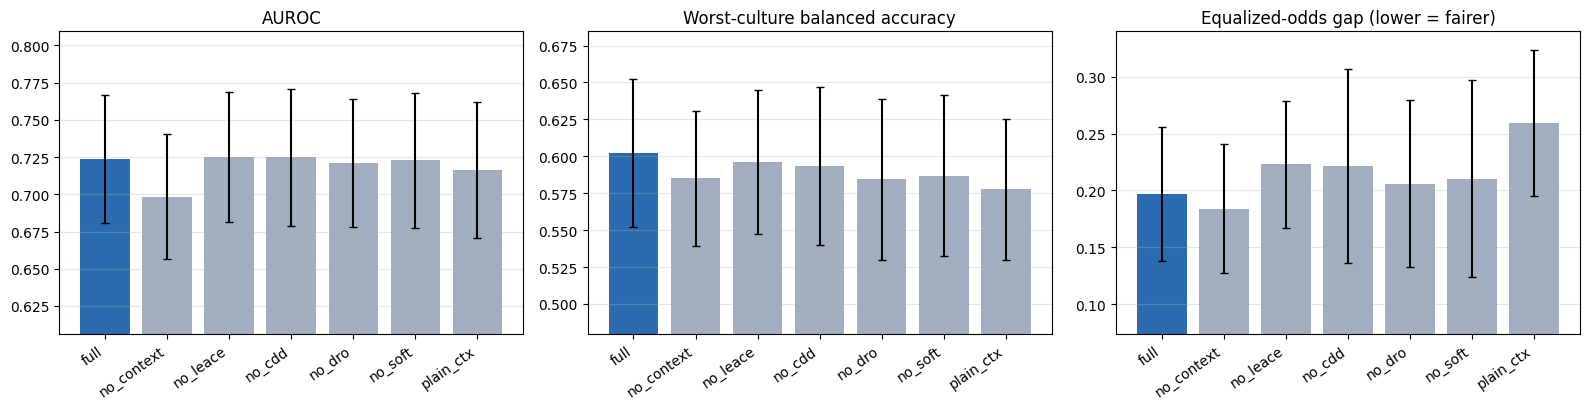

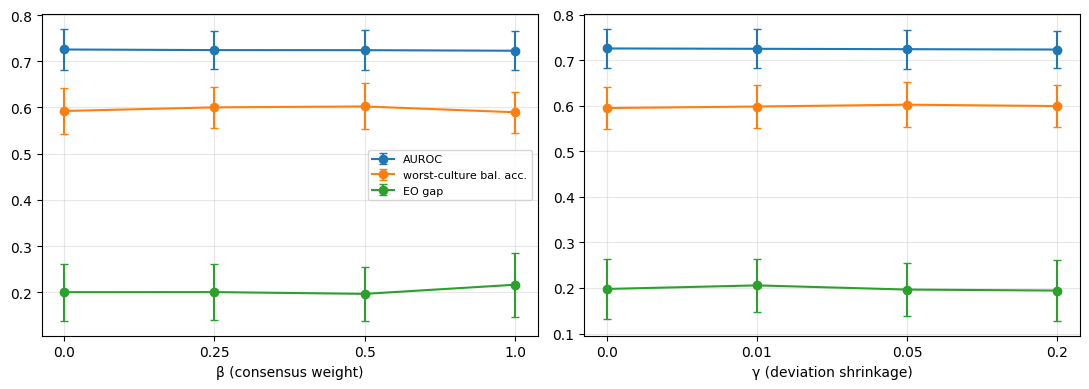

In [16]:
import matplotlib.pyplot as plt

def mean_sd(run, k):
    v = fold_metric(run, k); v = v[~np.isnan(v)]
    return v.mean(), v.std(ddof=1)

abl = [n for n, _, _ in ABLATIONS if os.path.exists(f"{RESULTS}/{n}/fold_metrics.json")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, k, title in zip(axes, ["auroc", "worst_culture_bal_acc", "equalized_odds_gap"],
                        ["AUROC", "Worst-culture balanced accuracy", "Equalized-odds gap (lower = fairer)"]):
    ms = [mean_sd(n, k) for n in abl]
    ax.bar(range(len(abl)), [m for m, _ in ms], yerr=[s for _, s in ms], capsize=3,
           color=["#2b6cb0" if n == "full" else "#a0aec0" for n in abl])
    ax.set_xticks(range(len(abl))); ax.set_xticklabels(abl, rotation=35, ha="right")
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    lo = min(m - s for m, s in ms); ax.set_ylim(max(0, lo - 0.05), None)
plt.tight_layout(); plt.savefig(f"{RESULTS}/ablation_bars.png", dpi=200); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, prefix, vals, label in [(axes[0], "beta", [0.0, 0.25, 0.5, 1.0], "β (consensus weight)"),
                                (axes[1], "gamma", [0.0, 0.01, 0.05, 0.2], "γ (deviation shrinkage)")]:
    runs = [("full" if (prefix == "beta" and v == 0.5) or (prefix == "gamma" and v == 0.05) else f"{prefix}{v:g}") for v in vals]
    for k, lab in [("auroc", "AUROC"), ("worst_culture_bal_acc", "worst-culture bal. acc."), ("equalized_odds_gap", "EO gap")]:
        ok = [(v, r) for v, r in zip(vals, runs) if os.path.exists(f"{RESULTS}/{r}/fold_metrics.json")]
        ms = [mean_sd(r, k) for _, r in ok]
        ax.errorbar([str(v) for v, _ in ok], [m for m, _ in ms], yerr=[s for _, s in ms], marker="o", capsize=3, label=lab)
    ax.set_xlabel(label); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{RESULTS}/sensitivity.png", dpi=200); plt.show()

In [17]:
import shutil
shutil.make_archive("/kaggle/working/step7_results", "zip", RESULTS)
print("Download /kaggle/working/step7_results.zip from the Output tab.")

Download /kaggle/working/step7_results.zip from the Output tab.


## What to send back
Upload **`step7_results.zip`** (ablation table, significance vs. full model, disagreement alignment, two figures, per-fold predictions).